# Imports and Downloads

In [2]:
import nltk
from nltk.corpus import brown

nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

# Load Dataset

In [3]:
total_categories = brown.categories()
all_words = brown.words()
untagged_sentences = brown.sents()
sentences = brown.tagged_sents(tagset='universal')

print("Total words:", len(all_words))
print(" ")
print("Total categories:", len(total_categories))
print(" ")
print("Total sentences:", len(sentences))
print(" ")
print("Tagged sentence:")
print(sentences[0])

Total words: 1161192
 
Total categories: 15
 
Total sentences: 57340
 
Tagged sentence:
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


# Shuffle and Split Dataset

In [4]:
import random

sentences = list(sentences)
random.seed(42)
random.shuffle(sentences)

split_index = int(0.8 * len(sentences))

train_data = sentences[:split_index]
test_data = sentences[split_index:]

print("Training sentences:", len(train_data))
print("Testing sentences:", len(test_data))

Training sentences: 45872
Testing sentences: 11468


# Create Count Dictionaries

In [5]:
from collections import defaultdict, Counter

# Count structures

initial_counts = Counter()

transition_counts = defaultdict(Counter)

emission_counts = defaultdict(Counter)

tag_counts = Counter()

vocabulary = set()

tags = set()

# Count Frequencies

In [6]:
for sentence in train_data:
    
    previous_tag = None
    
    for index, (word, tag) in enumerate(sentence):
        
        word = word.lower()
        
        vocabulary.add(word)
        tags.add(tag)
        
        tag_counts[tag] += 1
        
        # Initial tag count
        if index == 0:
            initial_counts[tag] += 1
        
        # Transition count
        if previous_tag is not None:
            transition_counts[previous_tag][tag] += 1
        
        # Emission count
        emission_counts[tag][word] += 1
        
        previous_tag = tag

# Convert Tags to List

In [7]:
tags = list(tags)

print("Tags:", tags)
print("Vocabulary size:", len(vocabulary))

Tags: ['ADV', 'NOUN', 'DET', 'VERB', 'CONJ', 'ADP', 'NUM', 'PRT', 'PRON', '.', 'ADJ', 'X']
Vocabulary size: 45153


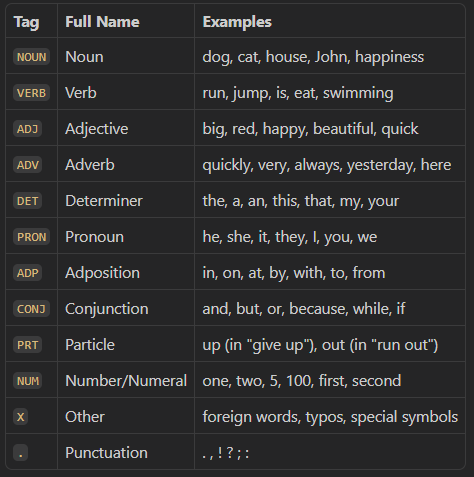

# Compute Initial Probabilities (π)

In [8]:
pi = {}

total_sentences = len(train_data)

for tag in tags:
    pi[tag] = initial_counts[tag] / total_sentences

#print(pi)

# Compute Transition Probabilities (A)

In [9]:
A = {}

for prev_tag in tags:
    
    A[prev_tag] = {}
    
    total_transitions = sum(transition_counts[prev_tag].values())
    
    for curr_tag in tags:
        
        if total_transitions > 0:
            A[prev_tag][curr_tag] = (
                transition_counts[prev_tag][curr_tag]
                / total_transitions
            )
        else:
            A[prev_tag][curr_tag] = 0.0
#print(A)

# Log-Space Viterbi Algorithm

In [10]:
import math

def log_viterbi(sentence, tags, A, B, pi):
    
    epsilon = 1e-12
    
    sentence = [word.lower() for word in sentence]
    
    V = []
    
    backpointer = []
    
    # Initialization
    V.append({})
    backpointer.append({})
    
    first_word = sentence[0]
    
    for tag in tags:
        
        emission_prob = B[tag].get(first_word, B[tag]["<OOV>"])
        
        V[0][tag] = (
            math.log(pi.get(tag, epsilon) + epsilon)
            +
            math.log(emission_prob + epsilon)
        )
        
        backpointer[0][tag] = None
    
    # Forward pass
    for t in range(1, len(sentence)):
        
        V.append({})
        backpointer.append({})
        
        word = sentence[t]
        
        for curr_tag in tags:
            
            best_score = float('-inf')
            best_prev_tag = None
            
            emission_prob = B[curr_tag].get(
                word,
                B[curr_tag]["<OOV>"]
            )
            
            for prev_tag in tags:
                
                transition_prob = A[prev_tag].get(curr_tag, 0.0)
                
                score = (
                    V[t - 1][prev_tag]
                    +
                    math.log(transition_prob + epsilon)
                    +
                    math.log(emission_prob + epsilon)
                )
                
                if score > best_score:
                    best_score = score
                    best_prev_tag = prev_tag
            
            V[t][curr_tag] = best_score
            backpointer[t][curr_tag] = best_prev_tag
    
    # Termination
    best_final_tag = max(V[-1], key=V[-1].get)
    
    # Backtracking
    best_tags = [best_final_tag]
    
    for t in range(len(sentence) - 1, 0, -1):
        
        best_final_tag = backpointer[t][best_final_tag]
        best_tags.insert(0, best_final_tag)
    
    return best_tags

In [11]:
from sklearn.model_selection import ParameterGrid

val_size = int(0.1 * len(train_data))
val_data = train_data[:val_size]
gs_train = train_data[val_size:]

print(f"Grid-search train : {len(gs_train)} sentences")
print(f"Validation        : {len(val_data)} sentences")

vocab_size = len(vocabulary)

gs_emission_counts = defaultdict(Counter)
gs_tag_counts      = Counter()

for sentence in gs_train:
    for word, tag in sentence:
        word = word.lower()
        gs_emission_counts[tag][word] += 1
        gs_tag_counts[tag]            += 1

def build_B_gs(alpha):
    B_gs = {}
    for tag in tags:
        total = gs_tag_counts[tag]
        denom = total + alpha * (vocab_size + 1)
        B_gs[tag] = {word: (gs_emission_counts[tag][word] + alpha) / denom
                     for word in vocabulary}
        B_gs[tag]["<OOV>"] = alpha / denom
    return B_gs

def evaluate_accuracy(sentences, B_eval):
    correct = total = 0
    for sentence in sentences:
        words     = [w for w, _ in sentence]
        true_tags = [t for _, t in sentence]
        predicted = log_viterbi(words, tags, A, B_eval, pi)
        for t, p in zip(true_tags, predicted):
            total   += 1
            correct += (t == p)
    return correct / total

param_grid = {'alpha': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1]}

print(f"\nSearching over {len(param_grid['alpha'])} alpha values...\n")
print(f"{'Alpha':<12} {'Val Accuracy':>14}")
print("-" * 28)

grid_results = []

for params in ParameterGrid(param_grid):
    B_candidate = build_B_gs(params['alpha'])
    val_acc     = evaluate_accuracy(val_data, B_candidate)
    grid_results.append((val_acc, params['alpha']))
    print(f"{params['alpha']:<12} {val_acc * 100:>13.4f}%")

grid_results.sort(reverse=True)
best_acc, best_alpha = grid_results[0]

print(f"\nBest alpha: {best_alpha}  →  {best_acc * 100}% validation accuracy")

Grid-search train : 41285 sentences
Validation        : 4587 sentences

Searching over 8 alpha values...

Alpha          Val Accuracy
----------------------------
1e-12              95.8496%
1e-11              95.8496%
1e-10              95.8507%
1e-09              95.8529%
1e-08              95.8409%
1e-07              95.6834%
1e-06              95.4712%
1                  93.4885%

Best alpha: 1e-09  →  95.85292766683435% validation accuracy


# Compute Emission Probabilities with Laplace Smoothing (B)

In [12]:
B = {}

vocab_size = len(vocabulary)

for tag in tags:
    
    B[tag] = {}
    
    total_tag_count = tag_counts[tag]
    
    # Compute probabilities for known words
    for word in vocabulary:
        
        count = emission_counts[tag][word]
        
        B[tag][word] = (
            (count + best_alpha)
            /
            (total_tag_count + best_alpha * (vocab_size + 1))
        )
    
    # OOV probability
    B[tag]["<OOV>"] = (
        best_alpha
        /
        (total_tag_count + best_alpha * (vocab_size + 1))
    )

print(f"B computed using best_alpha = {best_alpha}")

B computed using best_alpha = 1e-09


In [13]:
print(len(pi), len(A), len(B))

12 12 12


# Evaluate Accuracy

In [14]:
correct = 0
total = 0

failed_sentences = []

for sentence in test_data:
    
    words = [word for word, tag in sentence]
    
    true_tags = [tag for word, tag in sentence]
    
    predicted_tags = log_viterbi(
        words,
        tags,
        A,
        B,
        pi
    )
    
    sentence_correct = True
    
    for true_tag, predicted_tag in zip(true_tags, predicted_tags):
        
        total += 1
        
        if true_tag == predicted_tag:
            correct += 1
        else:
            sentence_correct = False
    
    # Store failed examples
    if not sentence_correct and len(failed_sentences) < 5:
        
        failed_sentences.append({
            "words": words,
            "true": true_tags,
            "predicted": predicted_tags
        })

accuracy = correct / total

print("Total words:", total)
print("Correct predictions:", correct)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

Total words: 232177
Correct predictions: 223015

Accuracy: 96.05 %


# Error Analysis

In [15]:
print("ERROR ANALYSIS")
print("=" * 60)

for index, example in enumerate(failed_sentences):
    
    print("\nExample", index + 1)
    
    print("\nSentence:")
    print(" ".join(example["words"]))
    
    print("\nTrue Tags:")
    print(example["true"])
    
    print("\nPredicted Tags:")
    print(example["predicted"])
    
    print("\n" + "-" * 60)

ERROR ANALYSIS

Example 1

Sentence:
According to state law a slave had to be at least thirty years old before he could be freed .

True Tags:
['ADP', 'ADP', 'NOUN', 'NOUN', 'DET', 'NOUN', 'VERB', 'PRT', 'VERB', 'ADP', 'ADJ', 'NUM', 'NOUN', 'ADJ', 'ADP', 'PRON', 'VERB', 'VERB', 'VERB', '.']

Predicted Tags:
['ADV', 'ADP', 'NOUN', 'NOUN', 'DET', 'NOUN', 'VERB', 'PRT', 'VERB', 'ADP', 'ADJ', 'NUM', 'NOUN', 'ADJ', 'ADP', 'PRON', 'VERB', 'VERB', 'VERB', '.']

------------------------------------------------------------

Example 2

Sentence:
With tips , the girls average between $150 and $200 a week , depending on basic salary .

True Tags:
['ADP', 'NOUN', '.', 'DET', 'NOUN', 'VERB', 'ADP', 'NOUN', 'CONJ', 'NOUN', 'DET', 'NOUN', '.', 'ADP', 'ADP', 'ADJ', 'NOUN', '.']

Predicted Tags:
['ADP', 'NOUN', '.', 'DET', 'NOUN', 'NOUN', 'ADP', 'NOUN', 'CONJ', 'NOUN', 'DET', 'NOUN', '.', 'VERB', 'ADP', 'ADJ', 'NOUN', '.']

------------------------------------------------------------

Example 3

Sentenc